In [15]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import h5py
import inspect
from tqdm import tqdm
import sys
import math
import glob
import matplotlib.cm as cm
import matplotlib.colors as mcolors
%matplotlib widget

In [16]:
# Load Exp Data
def load_ExpData(file_, idx_str_):
    # Open hdf5 file
    with h5py.File(file_, "r") as dataset:
        # Data
        return dict(freq_comb=np.asarray(dataset[idx_str_]["freq comb"]),
                    freq_pump=np.asarray(dataset[idx_str_]["freq pumps"]),
                    pump_pwr_data=np.asarray(dataset[idx_str_]["pump pwr sweep"]),
                    pump_phase_data=np.asarray(dataset[idx_str_]["pump phase sweep"]),
                    df=np.asarray(dataset[idx_str_]["df"]),
                    USB=np.asarray(dataset[idx_str_]["USB"]),
                    )

## Extract quadrature data

In [17]:

folder = "/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/LKIPA Measurements/I:/LKiPA-Data/2026-04/Covariance"

# Get all HDF5 files in the folder
files = glob.glob(os.path.join(folder, "*.hdf5"))

# Pick the most recently modified one
file = max(files, key=os.path.getmtime)

print("Selected file:", file)

# Extract the run name automatically
run = os.path.basename(file).replace(".hdf5", "")
print("Run:", run)


Selected file: /home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/LKIPA Measurements/I:/LKiPA-Data/2026-04/Covariance/2026-04-02_12_33_19.hdf5
Run: 2026-04-02_12_33_19


In [18]:
usb = load_ExpData(
    file_ = file,
    idx_str_= run
    )['USB']
covariance=np.array(usb)

freqs = load_ExpData(
    file_ = file,
    idx_str_= run
    )['freq_comb']

# Attributes for saving figures
modes = int(len(freqs))         # NUMBER OF MODES
print('Modes = ' + str(modes))

p_amp = int(                    # PUMP POWER
    load_ExpData(
    file_ = file,
    idx_str_= run
    )['pump_pwr_data'] * 100
)
print('Pump Power = ' + str(p_amp))

fp = load_ExpData(                    # PUMP POWER
    file_ = file,
    idx_str_= run
    )['freq_pump'][0] / 1e9
print('Pump Frequency  = ' + str(fp) + 'GHz')


df = int(load_ExpData(                    # PUMP POWER
    file_ = file,
    idx_str_= run
    )['df'] // 1e3
)
print('df = ' + str(df) + 'kHz')

Modes = 45
Pump Power = 14
Pump Frequency  = 8.858GHz
df = 10kHz


## Create covariance matrix

In [19]:
def covariance_matrix(usb_arr):
    real_part = np.real(usb_arr)
    imag_part = np.imag(usb_arr)

    # Stack quadratures: [Re0, Im0, Re1, Im1, ...]
    xp_mat = np.empty((usb_arr.shape[0], usb_arr.shape[1]*2))
    xp_mat[:, 0::2] = real_part
    xp_mat[:, 1::2] = imag_part

    # Covariance over samples
    return np.cov(xp_mat, rowvar=False)

cov_mat = covariance_matrix(covariance)

def cov_rotation(cov_mat, theta):
    """Rotate covariance matrix by angle theta (radians)"""
    c, s = np.cos(theta), np.sin(theta)
    R = np.array(
        [[c, -s],
        [s, c]]
    )
    
    N = cov_mat.shape[0] // 2
    R_big = np.zeros((2*N, 2*N))
    for i in range(N):
        R_big[2*i:2*i+2, 2*i:2*i+2] = R
    
    return R_big @ cov_mat @ R_big.T

theta = -3*np.pi/16  # 45 degrees
cov_mat = cov_rotation(cov_mat, theta)

## Plot

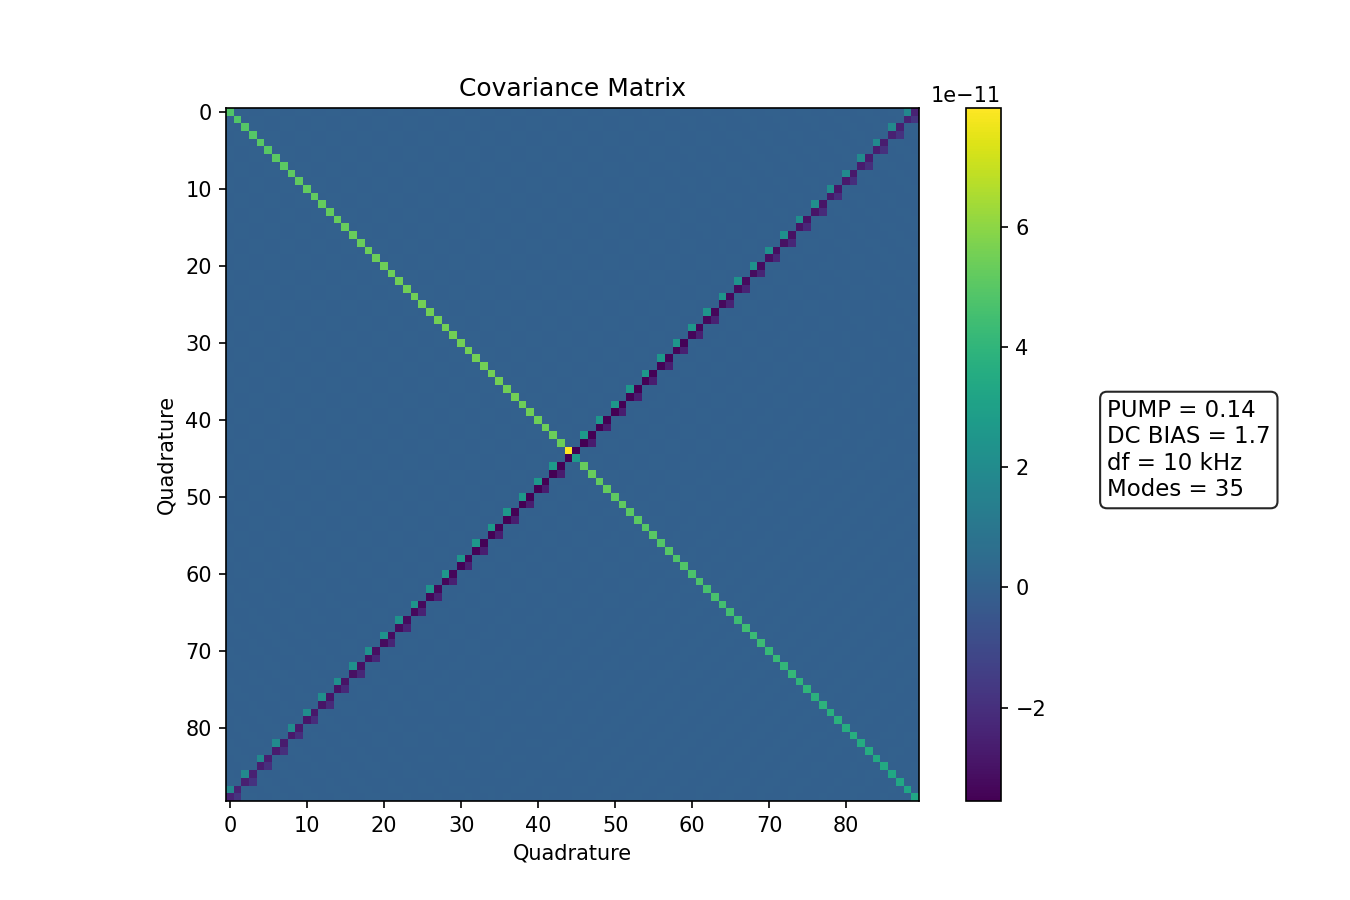

In [22]:
fig, ax = plt.subplots(figsize=(9, 6), dpi=150)

im = ax.imshow(
    cov_mat,
    aspect='equal',
    cmap='viridis',
    origin='upper',
#    vmax=5e-12,
#    vmin=-1e-9
)

cbar = fig.colorbar(im, ax=ax)


ax.set_xlabel("Quadrature")
ax.set_ylabel("Quadrature")
ax.set_title("Covariance Matrix")

# Make room on the right for the textbox
fig.subplots_adjust(right=0.82)

info_text = (
    f"PUMP = {0.14}" "\n"
    f"DC BIAS = {1.7}" "\n"
    f"df = 10 kHz" "\n" 
    f"Modes = 35"
)

fig.text(
    0.82, 0.5,                  # figure coordinates
    info_text,
    ha='left',
    va='center',
    fontsize=11,
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        edgecolor='black',
        alpha=0.85
    )
)

plt.savefig(
    fname=f'Figures/Covariance/LKIPA-Cov-modes={modes}-df={df}-run={run}-1pump_amp=0.14-pixels=4M.png'
)